# **Github**

In [1]:
import os
from getpass import getpass

github_pat = getpass("Enter your GitHub PAT: ")

!git clone https://$github_pat@github.com/mohassan5286/CV-Lab-3.git

os.chdir('CV-Lab-3')

!git checkout block-matching

Enter your GitHub PAT: ··········
Cloning into 'CV-Lab-3'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 26 (delta 1), reused 22 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 1.62 MiB | 10.28 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Branch 'block-matching' set up to track remote branch 'block-matching' from 'origin'.
Switched to a new branch 'block-matching'


# **Import Libraries**

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# **Hyperparameters**

In [3]:
max_disparity = 64

# **Utils**

In [4]:
def compute_loss(left_window, right_window, loss):
    diff = left_window.astype(np.float32) - right_window.astype(np.float32)

    if loss == 'SSD':
        return np.sum(diff**2)

    if loss == 'SAD':
        return np.sum(np.abs(diff))

#--------------------------------------------------------------#

def img_load(img_path, window_size):
    img = cv2.imread(img_path)

    padding_value = window_size // 2
    padded_image = cv2.copyMakeBorder(img, padding_value, padding_value, padding_value, padding_value, cv2.BORDER_CONSTANT)

    return padded_image

#--------------------------------------------------------------#

def compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity):

    left_padded_img, right_padded_img = img_load(left_img_path, window_size), img_load(right_img_path, window_size)

    pad = window_size // 2

    height, width = left_padded_img.shape[0] - 2 * pad, left_padded_img.shape[1] - 2 * pad

    disparity_map = np.zeros((height, width), dtype = np.uint8)


    for y in range(height):

        for x_l in range(width):

            min_loss = float('inf')
            best_disparity = 0

            y_pad = y + pad
            x_l_pad = x_l + pad

            for disparity in range(max_disparity):

                if (x_l - disparity) < 0:
                    break

                x_r_pad = x_l_pad - disparity

                left_window  = left_padded_img[y_pad - pad  : y_pad + pad + 1, x_l_pad - pad : x_l_pad + pad + 1]
                right_window = right_padded_img[y_pad - pad : y_pad + pad + 1, x_r_pad - pad : x_r_pad + pad + 1]

                current_loss = compute_loss(left_window, right_window, loss)

                if current_loss < min_loss:
                    min_loss = current_loss
                    best_disparity = disparity

            disparity_map[y, x_l] = best_disparity

    return disparity_map

# **Image 1**

In [5]:
left_img_path = 'Dataset/l1.png'
right_img_path = 'Dataset/r1.png'

### **Window-Size = 1 & Loss = SSD**

In [6]:
window_size = 1
loss = 'SSD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

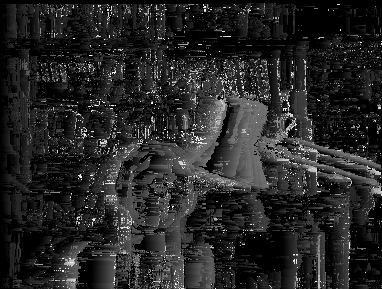

In [7]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 5 & Loss = SSD**

In [8]:
window_size = 5
loss = 'SSD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

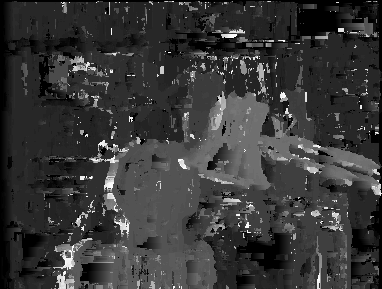

In [9]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 9 & Loss = SSD**

In [10]:
window_size = 9
loss = 'SSD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

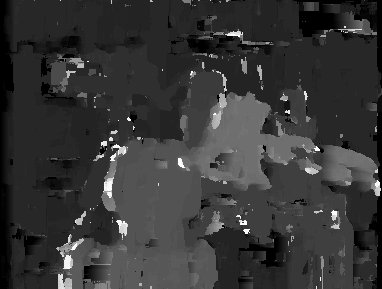

In [11]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 1 & Loss = SAD**

In [12]:
window_size = 1
loss = 'SAD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

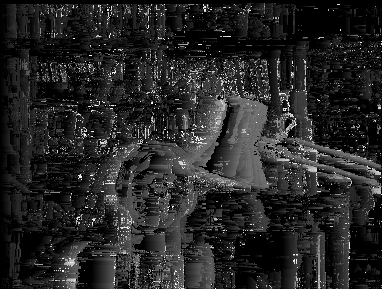

In [13]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 5 & Loss = SAD**

In [14]:
window_size = 5
loss = 'SAD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

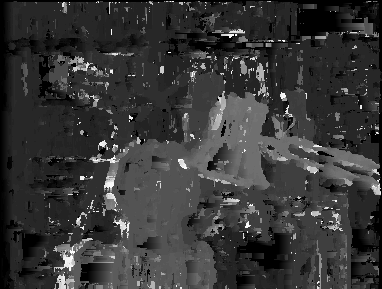

In [15]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 9 & Loss = SAD**

In [16]:
window_size = 9
loss = 'SAD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

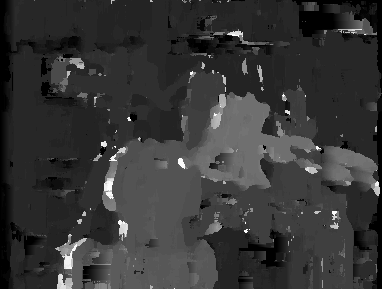

In [17]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

# **Image 2**

In [18]:
left_img_path = 'Dataset/l2.png'
right_img_path = 'Dataset/r2.png'

### **Window-Size = 1 & Loss = SSD**

In [19]:
window_size = 1
loss = 'SSD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

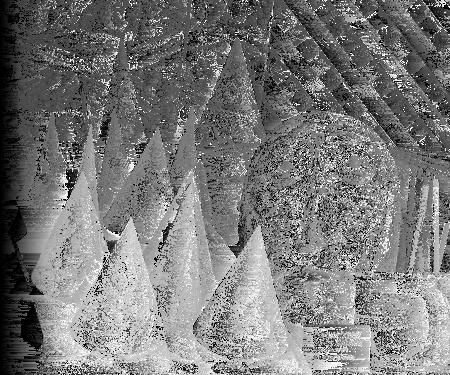

In [20]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 5 & Loss = SSD**

In [21]:
window_size = 5
loss = 'SSD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

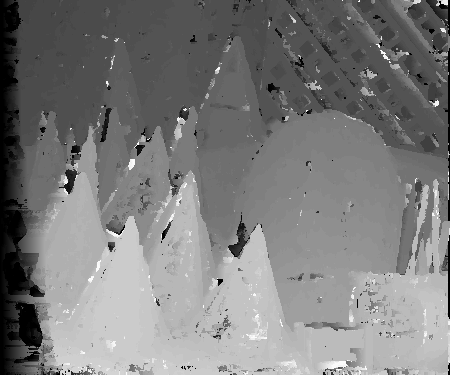

In [22]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 9 & Loss = SSD**

In [23]:
window_size = 9
loss = 'SSD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

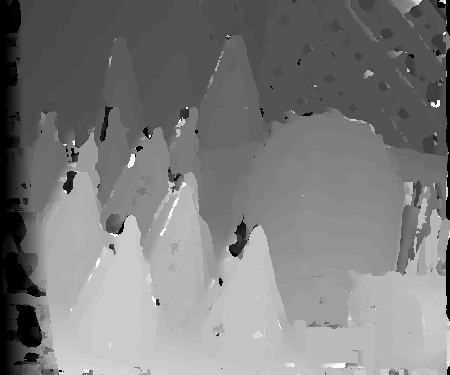

In [24]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 1 & Loss = SAD**

In [25]:
window_size = 1
loss = 'SAD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

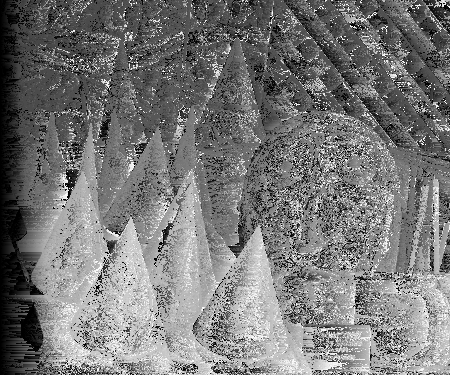

In [26]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 5 & Loss = SAD**

In [27]:
window_size = 5
loss = 'SAD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

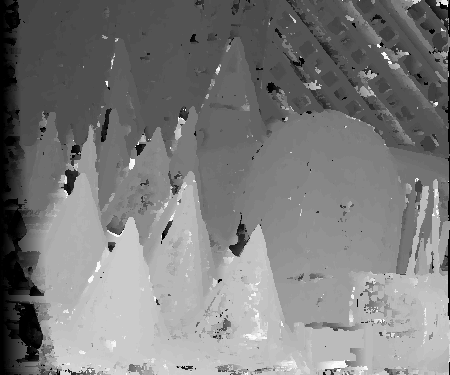

In [28]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 9 & Loss = SAD**

In [29]:
window_size = 9
loss = 'SAD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

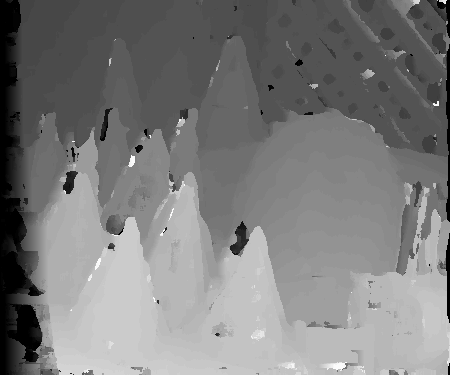

In [30]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

# **Image 3**

In [31]:
left_img_path = 'Dataset/l3.png'
right_img_path = 'Dataset/r3.png'

### **Window-Size = 1 & Loss = SSD**

In [32]:
window_size = 1
loss = 'SSD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

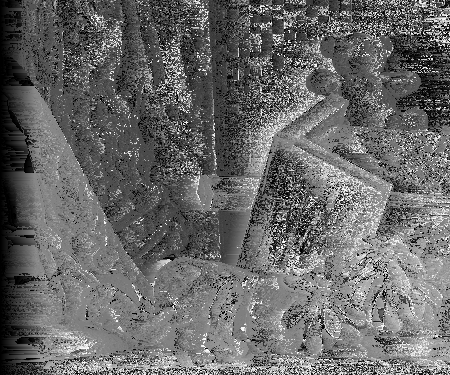

In [33]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 5 & Loss = SSD**

In [34]:
window_size = 5
loss = 'SSD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

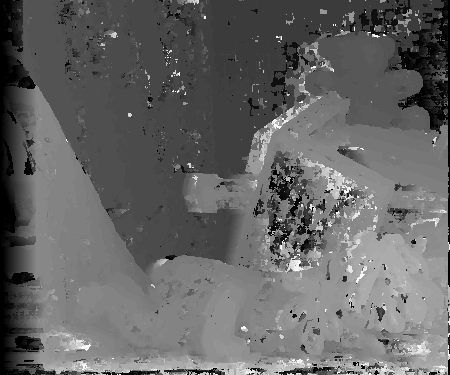

In [35]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 9 & Loss = SSD**

In [36]:
window_size = 9
loss = 'SSD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

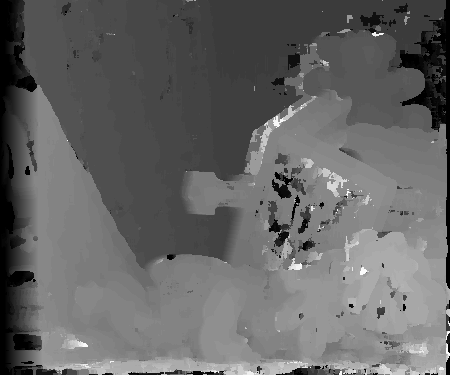

In [37]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 1 & Loss = SAD**

In [38]:
window_size = 1
loss = 'SAD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

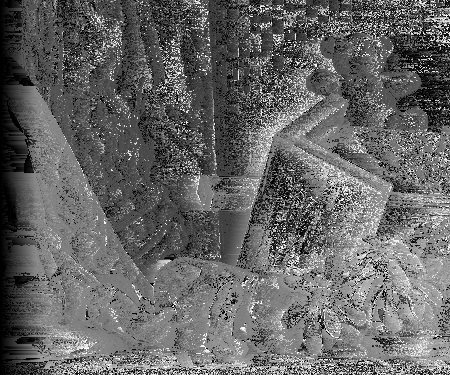

In [39]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 5 & Loss = SAD**

In [40]:
window_size = 5
loss = 'SAD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

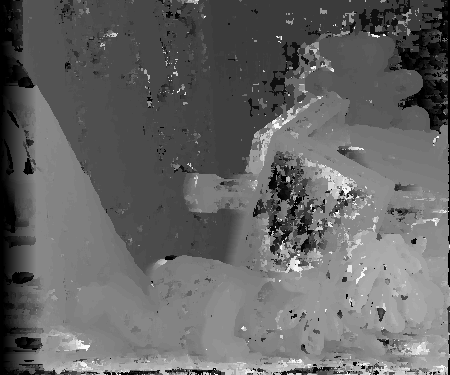

In [41]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)

### **Window-Size = 9 & Loss = SAD**

In [42]:
window_size = 9
loss = 'SAD'

disparity_map = compute_disparity_map(left_img_path, right_img_path, window_size, loss, max_disparity)

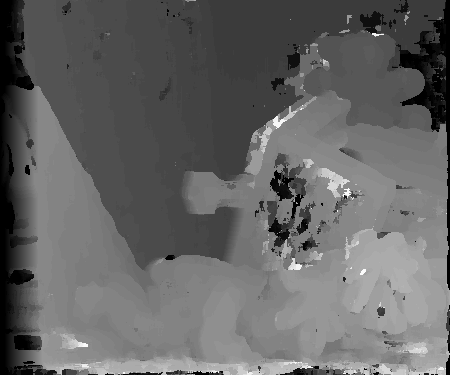

In [43]:
display_map = (disparity_map / max_disparity) * 255
display_map = display_map.astype(np.uint8)

cv2_imshow(display_map)